# Watermarking DCT Domain

Embed watermark biner ke foto wajah, kompresi JPEG berbagai QF, lalu evaluasi seberapa banyak bit yang salah setelah kompresi.



## Setup library dan foto

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import io

# Taruh foto wajah disini
IMAGE_PATH = '/Users/danesha/Desktop/Foto Rafeyfa Dea.png'

img_color = Image.open(IMAGE_PATH)
img_gray  = img_color.convert('L').resize((64, 64))
original  = np.array(img_gray, dtype=np.float64)

print(f"Shape: {original.shape} | min={original.min():.0f} | max={original.max():.0f}")

Shape: (64, 64) | min=20 | max=245


## Step 1: Load foto dan bagi jadi blok 8x8

Foto dikonversi ke grayscale dan di-resize ke 64x64.
Lalu dibagi jadi blok-blok 8x8 sebagai unit dasar DCT, sama seperti standar JPEG.

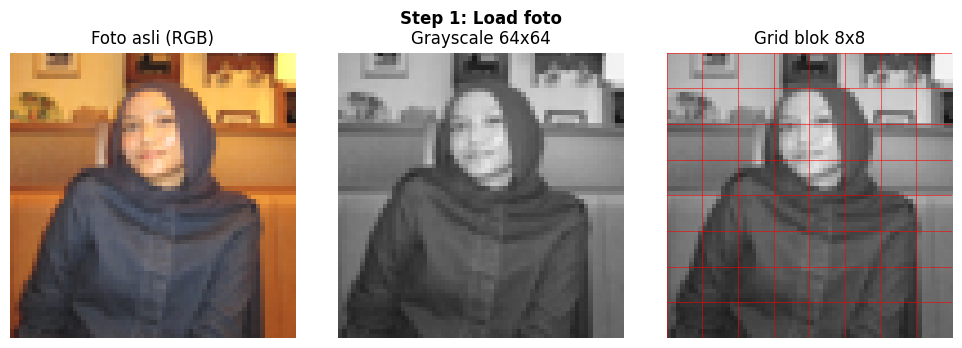

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

axes[0].imshow(np.array(img_color.resize((64,64))), origin='upper')
axes[0].set_title('Foto asli (RGB)')
axes[0].axis('off')

axes[1].imshow(original, cmap='gray', vmin=0, vmax=255, origin='upper')
axes[1].set_title('Grayscale 64x64')
axes[1].axis('off')

axes[2].imshow(original, cmap='gray', vmin=0, vmax=255, origin='upper')
for i in range(0, 65, 8):
    axes[2].axhline(i-0.5, color='red', lw=0.4)
    axes[2].axvline(i-0.5, color='red', lw=0.4)
axes[2].set_title('Grid blok 8x8')
axes[2].axis('off')

plt.suptitle('Step 1: Load foto', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 2: Buat watermark biner

Watermark adalah matriks 16x16 dengan pola "X": diagonal utama dan silang bernilai 1, sisanya 0.
Total 256 bit, tapi karena citra 64x64 hanya punya 64 blok 8x8, yang terpakai 64 bit pertama.

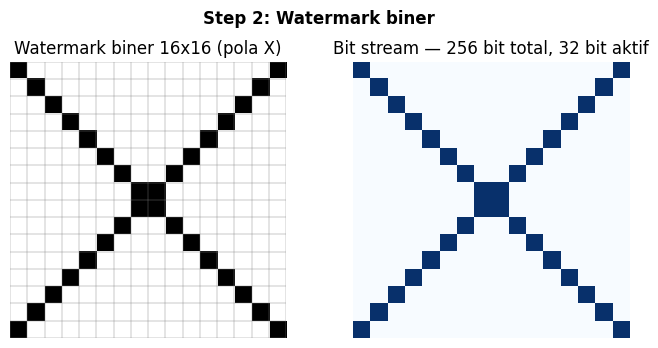

64 bit pertama (yang dipakai): [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]


In [52]:
# Helper functions (manual)
def make_list_2d(rows, cols, value=0):
    """Buat 2D list manual, sama kaya np.zeros()"""
    return [[value for _ in range(cols)] for _ in range(rows)]

def flatten_list_2d(arr_2d):
    """Flatten 2D list ke 1D, sama kaya .flatten()"""
    return [val for row in arr_2d for val in row]

def reshape_list(arr_1d, rows, cols):
    """Reshape 1D list ke 2D, sama kaya .reshape()"""
    result = []
    for i in range(rows):
        row = []
        for j in range(cols):
            row.append(arr_1d[i * cols + j])
        result.append(row)
    return result

def sum_list(arr):
    """Jumlah semua elemen, sama kaya np.sum()"""
    total = 0
    for val in arr:
        if isinstance(val, list):
            for v in val:
                total += v
        else:
            total += val
    return total

def make_watermark(size=16):
    """Buat watermark biner pola X - MANUAL tanpa np.zeros()"""
    wm = make_list_2d(size, size, 0)
    for i in range(size):
        # Diagonal utama
        wm[i][i] = 1
        # Diagonal silang
        wm[i][size-1-i] = 1
    return wm

wm_2d   = make_watermark(16)
wm_bits = flatten_list_2d(wm_2d)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))

# Convert ke numpy array untuk imshow (ini OK, matplotlib bawaan)
axes[0].imshow(np.array(wm_2d), cmap='binary', vmin=0, vmax=1, interpolation='nearest')
for i in range(17):
    axes[0].axhline(i-0.5, color='gray', lw=0.3)
    axes[0].axvline(i-0.5, color='gray', lw=0.3)
axes[0].set_title('Watermark biner 16x16 (pola X)')
axes[0].axis('off')

wm_bits_reshaped = reshape_list(wm_bits, 16, 16)
axes[1].imshow(np.array(wm_bits_reshaped), cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
n_bits_total = len(wm_bits)
n_bits_aktif = sum_list(wm_bits)
axes[1].set_title(f'Bit stream — {n_bits_total} bit total, {n_bits_aktif} bit aktif')
axes[1].axis('off')

plt.suptitle('Step 2: Watermark biner', fontweight='bold')
plt.tight_layout()
plt.show()
print(f"64 bit pertama (yang dipakai): {wm_bits[:64]}")

## Step 3: Fungsi DCT dan IDCT manual

DCT-II 2D dari formula lengkap — tidak pakai `scipy.fft` atau fungsi DCT bawaan manapun.

Koefisien kiri atas = frekuensi rendah (DC). Makin ke kanan-bawah = frekuensi tinggi.
Posisi embedding dipilih di mid-frequency: `[1,2]` dan `[2,1]` (zigzag index 5-6).
Mid-frequency dipilih karena cukup kuat untuk bertahan dari kompresi, tapi tidak merusak kualitas gambar secara kasat mata.

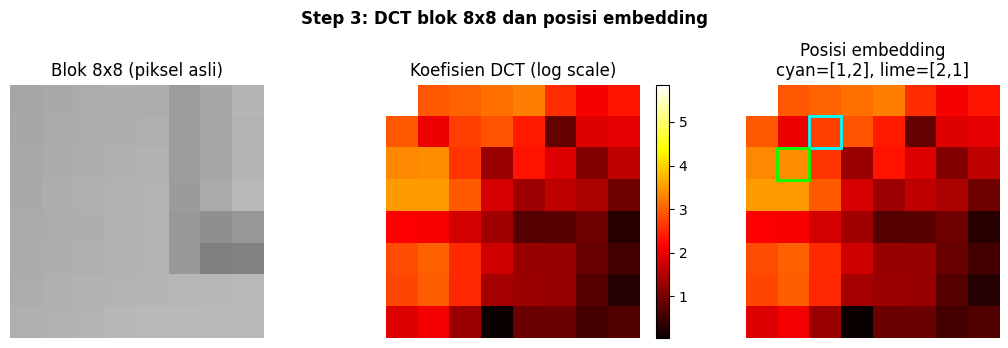

DC [0,0] = 346.75
[1,2]   = 14.12
[2,1]   = -28.80


In [53]:
def dct2(block):
    N = block.shape[0]
    result = np.zeros((N, N))
    for u in range(N):
        cu = (1/np.sqrt(2)) if u == 0 else 1.0
        for v in range(N):
            cv = (1/np.sqrt(2)) if v == 0 else 1.0
            s = 0.0
            for x in range(N):
                for y in range(N):
                    s += (block[x, y]
                          * np.cos((2*x+1)*u*np.pi/(2*N))
                          * np.cos((2*y+1)*v*np.pi/(2*N)))
            result[u, v] = (2/N) * cu * cv * s
    return result

def idct2(block):
    N = block.shape[0]
    result = np.zeros((N, N))
    for x in range(N):
        for y in range(N):
            s = 0.0
            for u in range(N):
                cu = (1/np.sqrt(2)) if u == 0 else 1.0
                for v in range(N):
                    cv = (1/np.sqrt(2)) if v == 0 else 1.0
                    s += (cu * cv * block[u, v]
                          * np.cos((2*x+1)*u*np.pi/(2*N))
                          * np.cos((2*y+1)*v*np.pi/(2*N)))
            result[x, y] = (2/N) * s
    return result

# Cek pada blok 8x8 pertama
blk = original[:8, :8] - 128
D   = dct2(blk)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))

axes[0].imshow(blk+128, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
axes[0].set_title('Blok 8x8 (piksel asli)')
axes[0].axis('off')

im1 = axes[1].imshow(np.log(np.abs(D)+1), cmap='hot', interpolation='nearest')
axes[1].set_title('Koefisien DCT (log scale)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
axes[1].axis('off')

axes[2].imshow(np.log(np.abs(D)+1), cmap='hot', interpolation='nearest')
r1 = patches.Rectangle((1.5,0.5),1,1,lw=2,edgecolor='cyan',facecolor='none')
r2 = patches.Rectangle((0.5,1.5),1,1,lw=2,edgecolor='lime',facecolor='none')
axes[2].add_patch(r1)
axes[2].add_patch(r2)
axes[2].set_title('Posisi embedding\ncyan=[1,2], lime=[2,1]')
axes[2].axis('off')

plt.suptitle('Step 3: DCT blok 8x8 dan posisi embedding', fontweight='bold')
plt.tight_layout()
plt.show()
print(f"DC [0,0] = {D[0,0]:.2f}")
print(f"[1,2]   = {D[1,2]:.2f}")
print(f"[2,1]   = {D[2,1]:.2f}")

## Step 4: Embed watermark

Tiap blok 8x8 menyimpan 1 bit:

- bit = 1: perkuat koefisien `[1,2]`, biarkan `[2,1]`
- bit = 0: perkuat koefisien `[2,1]`, biarkan `[1,2]`

Saat ekstraksi nanti: bandingkan keduanya, yang lebih besar menentukan bit.
`alpha=25` adalah kekuatan embedding.

Proses embed... (1-2 menit karena DCT manual)
Selesai.


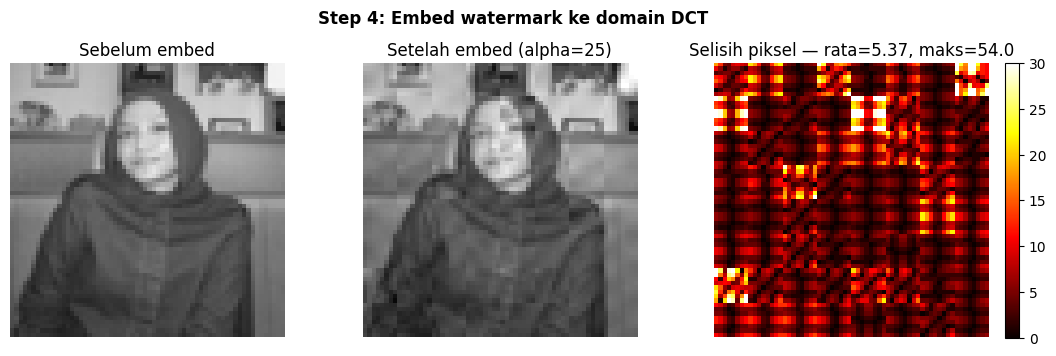

In [54]:
def clip(val, min_val, max_val):
    """Manual clipping - sama kaya np.clip()"""
    if val < min_val:
        return min_val
    elif val > max_val:
        return max_val
    else:
        return val

def embed(image, bits, alpha=25):
    img = image.astype(float)
    H, W = img.shape
    # Manual: copy array element by element
    out = [[img[i,j] for j in range(W)] for i in range(H)]
    idx = 0
    for r in range(0, H-7, 8):
        for c in range(0, W-7, 8):
            if idx >= len(bits):
                break
            blk = np.array([[img[r+i, c+j] - 128 for j in range(8)] for i in range(8)])
            D = dct2(blk)
            if bits[idx] == 1:
                D[1,2] = abs(D[1,2]) + alpha
                D[2,1] = abs(D[2,1])
            else:
                D[1,2] = abs(D[1,2])
                D[2,1] = abs(D[2,1]) + alpha
            
            idct_result = idct2(D)
            for i in range(8):
                for j in range(8):
                    out[r+i][c+j] = clip(idct_result[i,j] + 128, 0, 255)
            idx += 1
    
    # Convert back to numpy uint8 array
    result = np.zeros((H, W), dtype=np.uint8)
    for i in range(H):
        for j in range(W):
            result[i,j] = int(out[i][j])
    return result

print("Proses embed... (1-2 menit karena DCT manual)")
watermarked = embed(original, wm_bits, alpha=25)
print("Selesai.")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))

axes[0].imshow(original, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Sebelum embed')
axes[0].axis('off')

axes[1].imshow(watermarked, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('Setelah embed (alpha=25)')
axes[1].axis('off')

diff = np.abs(original - watermarked.astype(float))
im2 = axes[2].imshow(diff, cmap='hot', vmin=0, vmax=30)
axes[2].set_title(f'Selisih piksel — rata={diff.mean():.2f}, maks={diff.max():.1f}')
plt.colorbar(im2, ax=axes[2], fraction=0.046)
axes[2].axis('off')

plt.suptitle('Step 4: Embed watermark ke domain DCT', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5: Kompresi JPEG berbagai QF

QF kecil = kuantisasi kasar = banyak informasi DCT hilang = watermark rentan gagal.
QF besar = kualitas tinggi = watermark lebih terjaga.

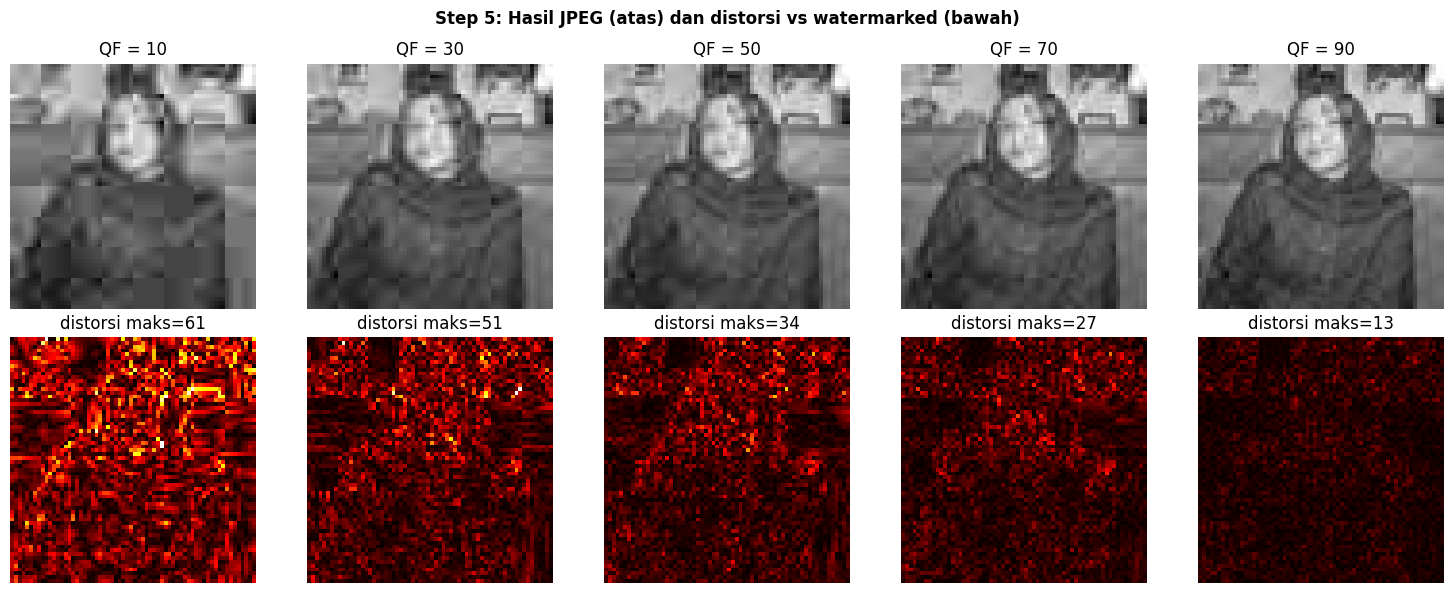

In [55]:
def jpeg_compress(arr, qf):
    buf = io.BytesIO()
    Image.fromarray(arr).save(buf, format='JPEG', quality=qf)
    buf.seek(0)
    return np.array(Image.open(buf).convert('L'))

qf_list = [10, 30, 50, 70, 90]
compressed = {}

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, qf in enumerate(qf_list):
    c = jpeg_compress(watermarked, qf)
    compressed[qf] = c

    axes[0,i].imshow(c, cmap='gray', vmin=0, vmax=255)
    axes[0,i].set_title(f'QF = {qf}')
    axes[0,i].axis('off')

    dist = np.abs(watermarked.astype(float) - c.astype(float))
    axes[1,i].imshow(dist, cmap='hot', vmin=0, vmax=50)
    axes[1,i].set_title(f'distorsi maks={dist.max():.0f}')
    axes[1,i].axis('off')

plt.suptitle('Step 5: Hasil JPEG (atas) dan distorsi vs watermarked (bawah)', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Ekstraksi watermark dan evaluasi BER

Ekstraksi: di tiap blok 8x8, bandingkan `|D[1,2]|` vs `|D[2,1]|`. Yang lebih besar = bit yang ditanam.

BER (Bit Error Rate) = proporsi bit yang salah setelah kompresi.
BER > 0.3 dianggap gagal — artinya lebih dari 30% bit tidak bisa dipulihkan.

In [56]:
def extract(image, n_bits):
    img = image.astype(float)
    H, W = img.shape
    bits = []
    for r in range(0, H-7, 8):
        for c in range(0, W-7, 8):
            if len(bits) >= n_bits:
                break
            D = dct2(img[r:r+8, c:c+8] - 128)
            bits.append(1 if abs(D[1,2]) > abs(D[2,1]) else 0)
    return bits

def ber(orig, ext):
    """Hitung BER - MANUAL tanpa np.sum()"""
    n = min(len(orig), len(ext))
    # Manual count errors
    error_count = 0
    for i in range(n):
        if orig[i] != ext[i]:
            error_count += 1
    return error_count / n if n > 0 else 0

print("Proses ekstraksi...")
results = {}
for qf in qf_list:
    e = extract(compressed[qf], len(wm_bits))
    b = ber(wm_bits, e)
    results[qf] = {'extracted': e, 'ber': b}
    status = 'GAGAL' if b > 0.3 else 'OK'
    print(f"  QF={qf:3d} | BER={b:.4f} | {status}")
print("Selesai.")

Proses ekstraksi...
  QF= 10 | BER=0.3438 | GAGAL
  QF= 30 | BER=0.1875 | OK
  QF= 50 | BER=0.1406 | OK
  QF= 70 | BER=0.1719 | OK
  QF= 90 | BER=0.1562 | OK
Selesai.


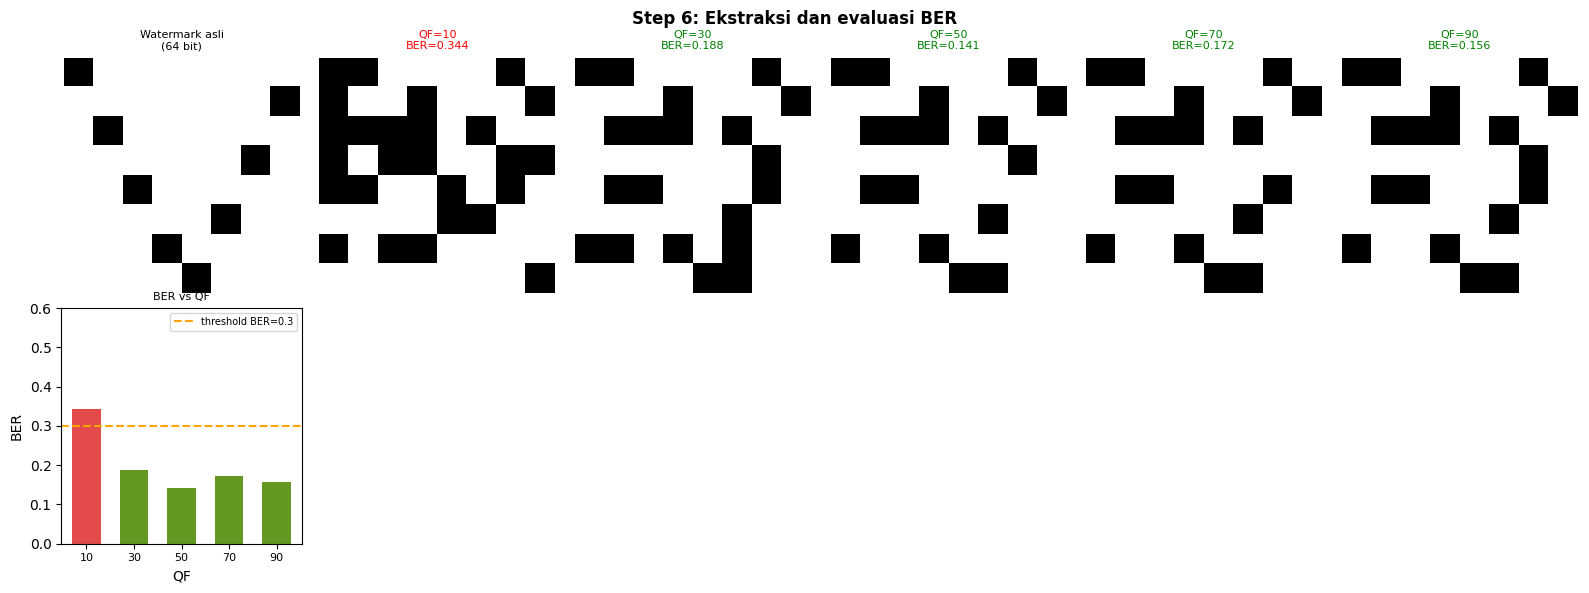

In [57]:
# Visualisasi ekstraksi dan grafik BER
fig, axes = plt.subplots(2, 6, figsize=(16, 6))

# Original watermark
original_bits_reshaped = reshape_list(wm_bits[:64], 8, 8)
axes[0,0].imshow(np.array(original_bits_reshaped), cmap='binary', vmin=0, vmax=1, interpolation='nearest')
axes[0,0].set_title('Watermark asli\n(64 bit)', fontsize=8)
axes[0,0].axis('off')

for i, qf in enumerate(qf_list):
    b = results[qf]['ber']
    color = 'red' if b > 0.3 else 'green'
    extracted_reshaped = reshape_list(results[qf]['extracted'][:64], 8, 8)
    axes[0,i+1].imshow(np.array(extracted_reshaped),
                       cmap='binary', vmin=0, vmax=1, interpolation='nearest')
    axes[0,i+1].set_title(f'QF={qf}\nBER={b:.3f}', color=color, fontsize=8)
    axes[0,i+1].axis('off')

# Grafik BER
ax = axes[1,0]
colors_bar = ['#E24B4A' if results[qf]['ber'] > 0.3 else '#639922' for qf in qf_list]
ber_values = [results[qf]['ber'] for qf in qf_list]
ax.bar(range(len(qf_list)), ber_values,
       color=colors_bar, width=0.6, edgecolor='none')
ax.axhline(0.3, color='orange', lw=1.5, ls='--', label='threshold BER=0.3')
ax.set_xticks(range(len(qf_list)))
ax.set_xticklabels(qf_list, fontsize=8)
ax.set_xlabel('QF')
ax.set_ylabel('BER')
ax.set_ylim(0, 0.6)
ax.legend(fontsize=7)
ax.set_title('BER vs QF', fontsize=8)
for j in range(1,6): axes[1,j].axis('off')

plt.suptitle('Step 6: Ekstraksi dan evaluasi BER', fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7: Tabel hasil dan kesimpulan

In [58]:
print(f"{'QF':>5} | {'BER':>8} | {'Error bit':>12} | Status")
print("-" * 42)
for qf in qf_list:
    b = results[qf]['ber']
    n = len(wm_bits[:64])
    err = int(round(b * n))
    status = 'GAGAL (BER > 0.3)' if b > 0.3 else 'OK'
    print(f"{qf:>5} | {b:>8.4f} | {err:>5}/{n:>5}      | {status}")

print()
# Find failed QF
failed = []
safe_qf = None
for qf in qf_list:
    if results[qf]['ber'] > 0.3:
        failed.append(qf)
    else:
        if safe_qf is None or qf < safe_qf:
            safe_qf = qf

if failed:
    print(f"Watermark gagal diekstrak pada QF: {failed}")
    if safe_qf:
        print(f"QF minimum yang aman: {safe_qf}")
else:
    print("Watermark berhasil diekstrak di semua QF yang diuji.")

   QF |      BER |    Error bit | Status
------------------------------------------
   10 |   0.3438 |    22/   64      | GAGAL (BER > 0.3)
   30 |   0.1875 |    12/   64      | OK
   50 |   0.1406 |     9/   64      | OK
   70 |   0.1719 |    11/   64      | OK
   90 |   0.1562 |    10/   64      | OK

Watermark gagal diekstrak pada QF: [10]
QF minimum yang aman: 30
